<h1>ACDC Main Demo</h1>

<p>This notebook (which doubles as a script) shows several use cases of ACDC</p>

<p>The codebase is built on top of https://github.com/neelnanda-io/TransformerLens (source version)</p>

<h3>Setup:</h3>
<p>Janky code to do different setup when run in a Colab notebook vs VSCode (adapted from e.g <a href="https://github.com/neelnanda-io/TransformerLens/blob/5c89b7583e73ce96db5e46ef86a14b15f303dde6/demos/Activation_Patching_in_TL_Demo.ipynb">this notebook</a>)</p>

In [23]:
!rm -rf ims/

In [24]:
try:
    import google.colab

    IN_COLAB = True
    print("Running as a Colab notebook")

    import subprocess # to install graphviz dependencies
    command = ['apt-get', 'install', 'graphviz-dev']
    subprocess.run(command, check=True)

    import os # make images folder
    os.mkdir("ims/")

    from IPython import get_ipython
    ipython = get_ipython()

    ipython.run_line_magic( # install ACDC
        "pip",
        "install git+https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git@d89f7fa9cbd095202f3940c889cb7c6bf5a9b516",
    )

except Exception as e:
    IN_COLAB = False
    print("Running outside of colab")

    import numpy # crucial to not get cursed error
    import plotly

    plotly.io.renderers.default = "colab"  # added by Arthur so running as a .py notebook with #%% generates .ipynb notebooks that display in colab
    # disable this option when developing rather than generating notebook outputs

    import os # make images folder
    if not os.path.exists("ims/"):
        os.mkdir("ims/")

    from IPython import get_ipython

    ipython = get_ipython()
    if ipython is not None:
        print("Running as a notebook")
        ipython.run_line_magic("load_ext", "autoreload")  # type: ignore
        ipython.run_line_magic("autoreload", "2")  # type: ignore
    else:
        print("Running as a script")

Running as a Colab notebook
  Cloning https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git (to revision d89f7fa9cbd095202f3940c889cb7c6bf5a9b516) to /tmp/pip-req-build-dahm2_hw
  Running command git clone --filter=blob:none --quiet https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git /tmp/pip-req-build-dahm2_hw
  Running command git rev-parse -q --verify 'sha^d89f7fa9cbd095202f3940c889cb7c6bf5a9b516'
  Running command git fetch -q https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git d89f7fa9cbd095202f3940c889cb7c6bf5a9b516
  Running command git checkout -q d89f7fa9cbd095202f3940c889cb7c6bf5a9b516
  Resolved https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git to commit d89f7fa9cbd095202f3940c889cb7c6bf5a9b516
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/deepmind/tracr.git (to revision e75ecda) to /tmp/pip-install-zjj4f4rl/tracr_8

In [25]:
# Download packages
!apt-get install graphviz-dev -y > /dev/null
!pip install -q transformer_lens einops kaleido cmapy torchtyping wandb pygraphviz

# Download code in collab
!rm -rf Automatic-Circuit-Discovery #
!git clone https://github.com/ArthurConmy/Automatic-Circuit-Discovery.git
%cd Automatic-Circuit-Discovery
!git checkout -q d89f7fa9cbd095202f3940c889cb7c6bf5a9b516
%cd /content/

Cloning into 'Automatic-Circuit-Discovery'...
remote: Enumerating objects: 18990, done.
remote: Counting objects: 100% (1701/1701), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 18990 (delta 1556), reused 1454 (delta 1454), pack-reused 17289 (from 3)
Receiving objects: 100% (18990/18990), 114.39 MiB | 17.19 MiB/s, done.
Resolving deltas: 100% (13815/13815), done.
/content/Automatic-Circuit-Discovery
/content


<h2>Imports etc</h2>

In [26]:
import subprocess
import sys
import importlib
import os
import datetime
import time
# 1. Installation
print("Installing packages")
subprocess.run([
    sys.executable, "-m", "pip", "install", "-q",
    "transformer-lens==1.5.0", "einops", "kaleido", "cmapy", "wandb", "pygraphviz"
], check=True)

# 2. Clear cache
import site
importlib.reload(site)
importlib.invalidate_caches()

# 3. THE ULTIMATE IN-MEMORY BYPASSES

# A. HuggingFace Cache Fix (Protect transformer_lens)
import transformers
transformers.TRANSFORMERS_CACHE = "/tmp/hf_cache"

# B. Transformer Lens Rename Fix
import transformer_lens
sys.modules['transformer_lens.HookedTransformerConfig'] = transformer_lens
sys.modules['transformer_lens.HookedTransformer'] = transformer_lens
sys.modules['transformer_lens.ActivationCache'] = transformer_lens
sys.modules['transformer_lens.FactoredMatrix'] = transformer_lens

# C. Torchtyping & Typeguard Fix
import types
# Turnoff typeguard
dummy_typeguard = types.ModuleType("typeguard")
dummy_typeguard.typechecked = lambda func: func  # Return function
sys.modules["typeguard"] = dummy_typeguard

# Fake torchtyping
class DummyTensorType:
    def __getitem__(self, key):
        return self

dummy_torchtyping = types.ModuleType("torchtyping")
dummy_torchtyping.TensorType = DummyTensorType()
dummy_torchtyping.patch_typeguard = lambda *args, **kwargs: None
sys.modules["torchtyping"] = dummy_torchtyping


if '/content/Automatic-Circuit-Discovery' not in sys.path:
    sys.path.append('/content/Automatic-Circuit-Discovery')


import wandb
import IPython
from IPython.display import Image, display
import torch
import gc
from tqdm import tqdm
import networkx as nx
import huggingface_hub
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import einops
import yaml
from transformers import AutoModelForCausalLM, AutoConfig, AutoTokenizer

import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from plotly.subplots import make_subplots
import plotly.graph_objects as go

from transformer_lens.hook_points import HookedRootModule, HookPoint
from transformer_lens.HookedTransformer import (
    HookedTransformer,
)

try:
    from acdc.tracr_task.utils import (
        get_all_tracr_things,
        get_tracr_model_input_and_tl_model,
    )
except Exception as e:
    print(f"Could not import `tracr` because {e}; the rest of the file should work but you cannot use the tracr tasks")

from acdc.docstring.utils import get_all_docstring_things
from acdc.acdc_utils import (
    make_nd_dict,
    reset_network,
    shuffle_tensor,
    cleanup,
    ct,
    TorchIndex,
    Edge,
    EdgeType,
)  # these introduce several important classes !!!

from acdc.TLACDCCorrespondence import TLACDCCorrespondence
from acdc.TLACDCInterpNode import TLACDCInterpNode
from acdc.TLACDCExperiment import TLACDCExperiment

from acdc.acdc_utils import (
    kl_divergence,
)
from acdc.ioi.utils import (
    get_all_ioi_things,
    get_gpt2_small,
)
from acdc.induction.utils import (
    get_all_induction_things,
    get_validation_data,
    get_good_induction_candidates,
    get_mask_repeat_candidates,
)
from acdc.greaterthan.utils import get_all_greaterthan_things
from acdc.acdc_graphics import (
    build_colorscheme,
    show,
)
import argparse

torch.autograd.set_grad_enabled(False)
print("\n Success.")

# GPU check
assert torch.cuda.is_available(), "GPU was not found ! "


Installing packages
Could not import `tracr` because No module named 'imp'; the rest of the file should work but you cannot use the tracr tasks

 Success.


<h2>Setup Task</h2>

In [27]:
import os
import argparse
import torch
import transformers
from IPython import get_ipython

#
# Lock all tokenizer loadings
os.environ["TRANSFORMERS_USE_FAST"] = "True"

orig_auto = transformers.AutoTokenizer.from_pretrained
orig_gpt2 = transformers.GPT2Tokenizer.from_pretrained
orig_gpt2_fast = transformers.GPT2TokenizerFast.from_pretrained

def universal_tokenizer_patch(orig_fn):
    def patched_fn(pretrained_model_name_or_path, *args, **kwargs):
        if isinstance(pretrained_model_name_or_path, str) and "redwood" in pretrained_model_name_or_path:
            pretrained_model_name_or_path = "gpt2"
        kwargs['use_fast'] = True
        return orig_fn(pretrained_model_name_or_path, *args, **kwargs)
    return patched_fn

transformers.AutoTokenizer.from_pretrained = universal_tokenizer_patch(orig_auto)
transformers.GPT2Tokenizer.from_pretrained = universal_tokenizer_patch(orig_gpt2)
transformers.GPT2TokenizerFast.from_pretrained = universal_tokenizer_patch(orig_gpt2_fast)


ipython = get_ipython()
parser = argparse.ArgumentParser(description="Used to launch ACDC runs. Only task and threshold are required")

task_choices = ['ioi', 'docstring', 'induction', 'tracr-reverse', 'tracr-proportion', 'greaterthan']
parser.add_argument('--task', type=str, required=True, choices=task_choices, help=f'Choose a task from the available options: {task_choices}')
parser.add_argument('--threshold', type=float, required=True, help='Value for THRESHOLD')
parser.add_argument('--first-cache-cpu', type=str, required=False, default="True", help='Value for FIRST_CACHE_CPU')
parser.add_argument('--second-cache-cpu', type=str, required=False, default="True", help='Value for SECOND_CACHE_CPU')
parser.add_argument('--zero-ablation', action='store_true', help='Use zero ablation')
parser.add_argument('--using-wandb', action='store_true', help='Use wandb')
parser.add_argument('--wandb-entity-name', type=str, required=False, default="remix_school-of-rock")
parser.add_argument('--wandb-group-name', type=str, required=False, default="default")
parser.add_argument('--wandb-project-name', type=str, required=False, default="acdc")
parser.add_argument('--wandb-run-name', type=str, required=False, default=None)
parser.add_argument("--wandb-dir", type=str, default="/tmp/wandb")
parser.add_argument("--wandb-mode", type=str, default="online")
parser.add_argument('--indices-mode', type=str, default="normal")
parser.add_argument('--names-mode', type=str, default="normal")
parser.add_argument('--device', type=str, default="cuda")
parser.add_argument('--reset-network', type=int, default=0)
parser.add_argument('--metric', type=str, default="kl_div")
parser.add_argument('--torch-num-threads', type=int, default=0)
parser.add_argument('--seed', type=int, default=1234)
parser.add_argument("--max-num-epochs",type=int, default=100_000)
parser.add_argument('--single-step', action='store_true')
parser.add_argument("--abs-value-threshold", action='store_true')

if ipython is not None:
    args = parser.parse_args(
        [line.strip() for line in r"""--task=induction\
--threshold=0.8\
--zero-ablation\
--indices-mode=reverse\
--first-cache-cpu=False\
--second-cache-cpu=False\
--max-num-epochs=100000""".split("\\\n")]
    )
else:
    args = parser.parse_args()

if args.torch_num_threads > 0:
    torch.set_num_threads(args.torch_num_threads)
torch.manual_seed(args.seed)

TASK = args.task
if args.first_cache_cpu is None:
    ONLINE_CACHE_CPU = True
elif args.first_cache_cpu.lower() == "false":
    ONLINE_CACHE_CPU = False
elif args.first_cache_cpu.lower() == "true":
    ONLINE_CACHE_CPU = True
else:
    raise ValueError(f"first_cache_cpu must be either True or False")

if args.second_cache_cpu is None:
    CORRUPTED_CACHE_CPU = True
elif args.second_cache_cpu.lower() == "false":
    CORRUPTED_CACHE_CPU = False
elif args.second_cache_cpu.lower() == "true":
    CORRUPTED_CACHE_CPU = True
else:
    raise ValueError(f"second_cache_cpu must be either True or False")

THRESHOLD = args.threshold
ZERO_ABLATION = False if args.zero_ablation else False
USING_WANDB = True if args.using_wandb else False
WANDB_ENTITY_NAME = args.wandb_entity_name
WANDB_PROJECT_NAME = args.wandb_project_name
WANDB_RUN_NAME = args.wandb_run_name
WANDB_GROUP_NAME = args.wandb_group_name
INDICES_MODE = args.indices_mode
NAMES_MODE = args.names_mode
DEVICE = args.device
RESET_NETWORK = args.reset_network
SINGLE_STEP = True if args.single_step else False

# Data loading
print(f"Task: {TASK} with threshold: {THRESHOLD}...")

second_metric = None
use_pos_embed = TASK.startswith("tracr")

if TASK == "ioi":
    num_examples = 40
    things = get_all_ioi_things(
        num_examples=num_examples, device=DEVICE, metric_name=args.metric
    )
elif TASK == "tracr-reverse":
    num_examples = 6
    things = get_all_tracr_things(
        task="reverse",
        metric_name=args.metric,
        num_examples=num_examples,
        device=DEVICE,
    )
elif TASK == "tracr-proportion":
    num_examples = 50
    things = get_all_tracr_things(
        task="proportion",
        metric_name=args.metric,
        num_examples=num_examples,
        device=DEVICE,
    )
elif TASK == "induction":
    num_examples = 10
    seq_len = 300
    things = get_all_induction_things(
        num_examples=num_examples, seq_len=seq_len, device=DEVICE, metric=args.metric
    )
elif TASK == "docstring":
    num_examples = 50
    seq_len = 41
    things = get_all_docstring_things(
        num_examples=num_examples,
        seq_len=seq_len,
        device=DEVICE,
        metric_name=args.metric,
        correct_incorrect_wandb=True,
    )
elif TASK == "greaterthan":
    num_examples = 100
    things = get_all_greaterthan_things(
        num_examples=num_examples, metric_name=args.metric, device=DEVICE
    )
else:
    raise ValueError(f"Unknown task {TASK}")

print("\nSuccess!")


Task: induction with threshold: 0.8...
Loaded pretrained model redwood_attn_2l into HookedTransformer

Success!


<p> Let's define the four most important objects for ACDC experiments:

In [28]:

validation_metric = things.validation_metric # metric we use (e.g KL divergence)
toks_int_values = things.validation_data # clean data x_i
toks_int_values_other = things.validation_patch_data # corrupted data x_i'
tl_model = things.tl_model # transformerlens model

if RESET_NETWORK:
    reset_network(TASK, DEVICE, tl_model)


<h2>Setup ACDC Experiment</h2>

In [29]:
# Make notes for potential wandb run
try:
    with open(__file__, "r") as f:
        notes = f.read()
except:
    notes = "No notes generated, expected when running in an .ipynb file"

tl_model.reset_hooks()

# Save some mem
gc.collect()
torch.cuda.empty_cache()

# Setup wandb if needed
if WANDB_RUN_NAME is None or IPython.get_ipython() is not None:
    WANDB_RUN_NAME = f"{ct()}{'_randomindices' if INDICES_MODE=='random' else ''}_{THRESHOLD}{'_zero' if ZERO_ABLATION else ''}"
else:
    assert WANDB_RUN_NAME is not None, "I want named runs, always"

tl_model.reset_hooks()
exp = TLACDCExperiment(
    model=tl_model,
    threshold=THRESHOLD,
    using_wandb=USING_WANDB,
    wandb_entity_name=WANDB_ENTITY_NAME,
    wandb_project_name=WANDB_PROJECT_NAME,
    wandb_run_name=WANDB_RUN_NAME,
    wandb_group_name=WANDB_GROUP_NAME,
    wandb_notes=notes,
    wandb_dir=args.wandb_dir,
    wandb_mode=args.wandb_mode,
    wandb_config=args,
    zero_ablation=ZERO_ABLATION,
    abs_value_threshold=args.abs_value_threshold,
    ds=toks_int_values,
    ref_ds=toks_int_values_other,
    metric=validation_metric,
    second_metric=second_metric,
    verbose=True,
    indices_mode=INDICES_MODE,
    names_mode=NAMES_MODE,
    corrupted_cache_cpu=CORRUPTED_CACHE_CPU,
    hook_verbose=False,
    online_cache_cpu=ONLINE_CACHE_CPU,
    add_sender_hooks=True,
    use_pos_embed=use_pos_embed,
    add_receiver_hooks=False,
    remove_redundant=False,
    show_full_index=use_pos_embed,
)


dict_keys(['blocks.1.hook_resid_post', 'blocks.1.attn.hook_result', 'blocks.1.attn.hook_q', 'blocks.1.hook_q_input', 'blocks.1.attn.hook_k', 'blocks.1.hook_k_input', 'blocks.1.attn.hook_v', 'blocks.1.hook_v_input', 'blocks.0.attn.hook_result', 'blocks.0.attn.hook_q', 'blocks.0.hook_q_input', 'blocks.0.attn.hook_k', 'blocks.0.hook_k_input', 'blocks.0.attn.hook_v', 'blocks.0.hook_v_input', 'blocks.0.hook_resid_pre'])
ln_final.hook_normalized
ln_final.hook_scale
blocks.1.hook_resid_post
blocks.1.hook_attn_out
blocks.1.attn.hook_result
blocks.1.attn.hook_z
blocks.1.attn.hook_pattern
blocks.1.attn.hook_attn_scores
blocks.1.attn.hook_v
blocks.1.attn.hook_k
blocks.1.attn.hook_q
blocks.1.ln1.hook_normalized
blocks.1.ln1.hook_scale
blocks.1.hook_v_input
blocks.1.hook_k_input
blocks.1.hook_q_input
blocks.1.hook_resid_pre
blocks.0.hook_resid_post
blocks.0.hook_attn_out
blocks.0.attn.hook_result
blocks.0.attn.hook_z
blocks.0.attn.hook_pattern
blocks.0.attn.hook_attn_scores
blocks.0.attn.hook_v
blo

In [34]:
# Model config
print(tl_model.cfg)

HookedTransformerConfig:
{'act_fn': 'gelu_new',
 'attention_dir': 'causal',
 'attn_only': True,
 'attn_types': None,
 'checkpoint_index': None,
 'checkpoint_label_type': None,
 'checkpoint_value': None,
 'd_head': 32,
 'd_mlp': -1,
 'd_model': 256,
 'd_vocab': 50259,
 'd_vocab_out': 50259,
 'default_prepend_bos': True,
 'device': 'cuda',
 'dtype': torch.float32,
 'eps': 1e-05,
 'final_rms': False,
 'from_checkpoint': False,
 'gated_mlp': False,
 'init_mode': 'gpt2',
 'init_weights': False,
 'initializer_range': np.float64(0.05),
 'model_name': 'redwood_attn_2l',
 'n_ctx': 2048,
 'n_devices': 1,
 'n_heads': 8,
 'n_layers': 2,
 'n_params': 524288,
 'normalization_type': 'LN',
 'original_architecture': 'neel',
 'parallel_attn_mlp': False,
 'positional_embedding_type': 'shortformer',
 'rotary_dim': None,
 'scale_attn_by_inverse_layer_idx': False,
 'seed': None,
 'tokenizer_name': 'ArthurConmy/redwood_tokenizer',
 'use_attn_result': True,
 'use_attn_scale': True,
 'use_hook_mlp_in': True,
 

In [30]:
from IPython.display import Image, display
from acdc.acdc_graphics import show

print("Initial Edges:", exp.count_no_edges())
all_nodes = [
    node
    for receiver_dict in exp.corr.graph.values()
    for node in receiver_dict.values()
]

print("Initial Nodes:", len(all_nodes))
print("-" * 50)
show(
    exp.corr,
    "ims/initial_full_network.png",
    show_full_index=False,
)

display(Image("ims/initial_full_network.png"))
print("-" * 50)
print(exp.corr.nodes())
print("Initial connections")
for edge_tuple, edge in exp.corr.all_edges().items():
    if edge.present and edge.edge_type != EdgeType.PLACEHOLDER:
        receiver_name, receiver_idx, sender_name, sender_idx = edge_tuple

        rec_str = f"{receiver_name} {receiver_idx.hashable_tuple}"
        send_str = f"{sender_name} {sender_idx.hashable_tuple}"

        print(f"From: {send_str}  --->  To: {rec_str}")

No edge 305
Initial Edges: 305
Initial Nodes: 114
--------------------------------------------------


--------------------------------------------------
[TLACDCInterpNode(blocks.1.hook_resid_post, [:]), TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 7]), TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 6]), TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 5]), TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 4]), TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 3]), TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 2]), TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 1]), TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 0]), TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 7]), TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 6]), TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 5]), TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 4]), TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 3]), TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 2]), TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 1]), TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 0]), TLACDCInterpNode(blocks.1.attn.hook_k, [:, 

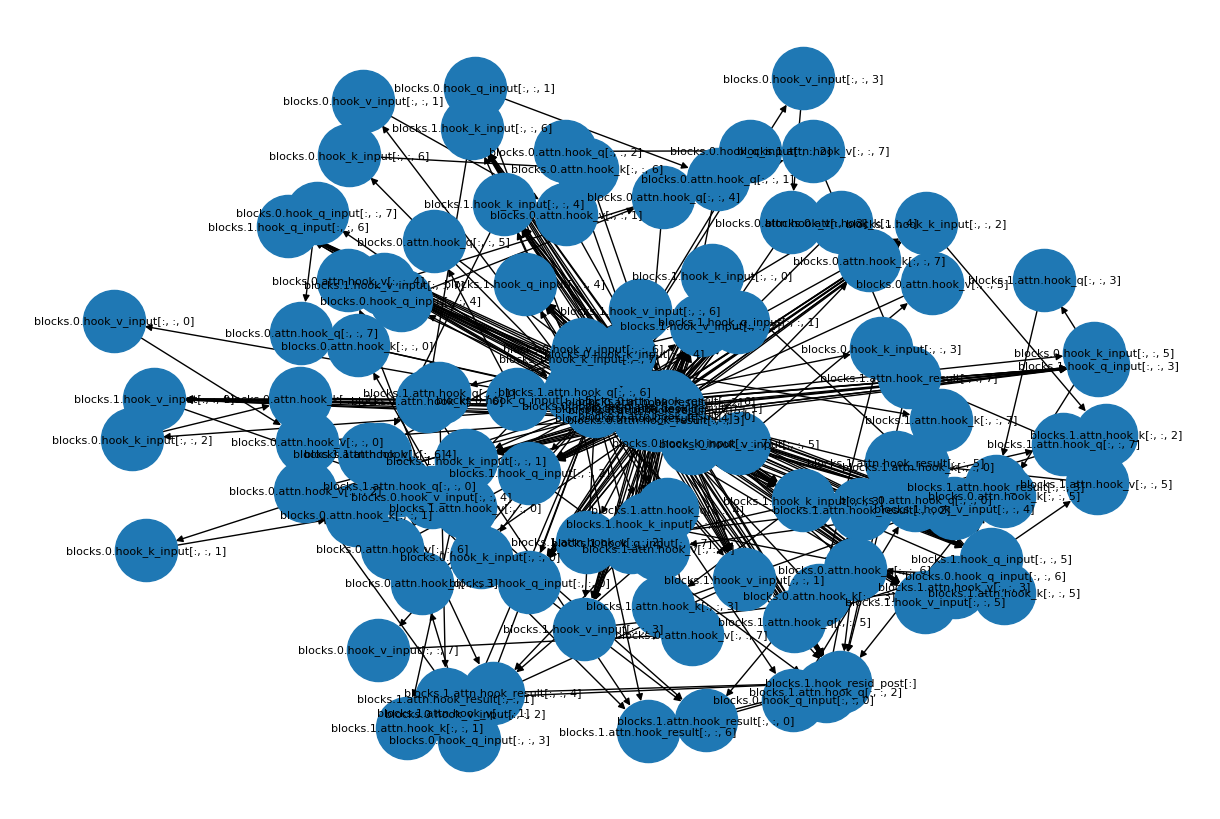

In [31]:
import networkx as nx

G = nx.DiGraph()

for (receiver_name, receiver_index, sender_name, sender_index), edge in exp.corr.all_edges().items():
    if not edge.present:
        continue

    src = f"{sender_name}{sender_index}"
    dst = f"{receiver_name}{receiver_index}"

    G.add_edge(src, dst)

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, k=0.5)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2000,
    font_size=8,
    arrows=True
)

plt.show()

<h2>Run steps of ACDC: iterate over a NODE in the model's computational graph</h2>
<p>WARNING! This will take a few minutes to run, but there should be rolling nice pictures too : )</p>

No edge 305
No edge 305
New metric: 0.0

Node: cur_parent=TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.1.hook_resid_post, [:]))

Metric after removing connection to blocks.1.attn.hook_result [:, :, 0] is 0.02825758419930935 (and current metric 0.0)
Result is 0.02825758419930935...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 1]) (self.current_node=TLACDCInterpNode(blocks.1.hook_resid_post, [:]))

Metric after removing connection to blocks.1.attn.hook_result [:, :, 1] is 0.03580968827009201 (and current metric 0.02825758419930935)
Result is 0.0075521040707826614...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.1.attn.hook_result, [:, :, 2]) (self.current_node=TLACDCInterpNode(blocks.1.hook_resid_post, [:]))

Metric after removing connection to blocks.1.attn.hook_result [:, :, 2] is 0.04275461286306381 (and current metric 0.03580968827009201)
Result is 0.006944924592971802

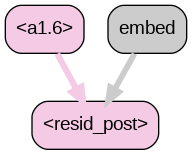

0 --------------------------------------------------
Edges remaining: 290
No edge 290
New metric: 2.727907657623291
No edge 290
No edge 290
No edge 290
We moved to  blocks.1.attn.hook_result[:, :, 5]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 4]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 3]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 2]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 1]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_result[:, :, 0]
No edge 290
No edge 290
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 7]
No edge 290
No edge 289
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 6]
No edge 289
No edge 289
Edge removed! New set: 289


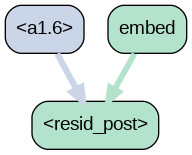

1 --------------------------------------------------
Edges remaining: 289
No edge 289
New metric: 2.727907657623291

Node: cur_parent=TLACDCInterpNode(blocks.1.hook_v_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.1.attn.hook_v, [:, :, 6]))

Metric after removing connection to blocks.1.hook_v_input [:, :, 6] is 8.469816207885742 (and current metric 2.727907657623291)
Result is 5.741908550262451...so keeping connection
No edge 289
We moved to  blocks.1.attn.hook_v[:, :, 5]
No edge 289
No edge 288
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 4]
No edge 288
No edge 287
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 3]
No edge 287
No edge 286
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 2]
No edge 286
No edge 285
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 1]
No edge 285
No edge 284
But it's bad
We moved to  blocks.1.attn.hook_v[:, :, 0]
No edge 284
No edge 283
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 7]
No edge 283
No edge 282
But i

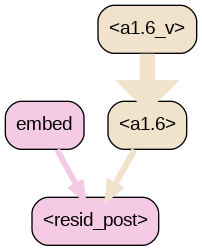

2 --------------------------------------------------
Edges remaining: 282
No edge 282
New metric: 2.727907657623291

Node: cur_parent=TLACDCInterpNode(blocks.1.hook_k_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.1.attn.hook_k, [:, :, 6]))

Metric after removing connection to blocks.1.hook_k_input [:, :, 6] is 7.78385591506958 (and current metric 2.727907657623291)
Result is 5.055948257446289...so keeping connection
No edge 282
We moved to  blocks.1.attn.hook_k[:, :, 5]
No edge 282
No edge 281
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 4]
No edge 281
No edge 280
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 3]
No edge 280
No edge 279
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 2]
No edge 279
No edge 278
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 1]
No edge 278
No edge 277
But it's bad
We moved to  blocks.1.attn.hook_k[:, :, 0]
No edge 277
No edge 276
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 7]
No edge 276
No edge 275
But it

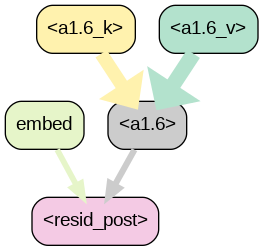

3 --------------------------------------------------
Edges remaining: 275
No edge 275
New metric: 2.727907657623291

Node: cur_parent=TLACDCInterpNode(blocks.1.hook_q_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.1.attn.hook_q, [:, :, 6]))

Metric after removing connection to blocks.1.hook_q_input [:, :, 6] is 7.850895881652832 (and current metric 2.727907657623291)
Result is 5.122988224029541...so keeping connection
No edge 275
We moved to  blocks.1.attn.hook_q[:, :, 5]
No edge 275
No edge 274
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 4]
No edge 274
No edge 273
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 3]
No edge 273
No edge 272
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 2]
No edge 272
No edge 271
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 1]
No edge 271
No edge 270
But it's bad
We moved to  blocks.1.attn.hook_q[:, :, 0]
No edge 270
No edge 269
But it's bad
We moved to  blocks.1.hook_v_input[:, :, 7]
No edge 269
No edge 260
But 

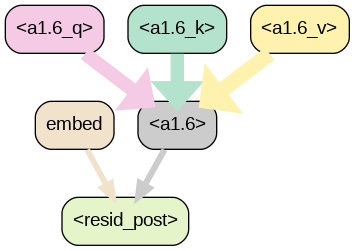

4 --------------------------------------------------
Edges remaining: 260
No edge 260
New metric: 2.727907657623291

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.1.hook_v_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 0] is 2.443183660507202 (and current metric 2.727907657623291)
Result is -0.28472399711608887...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 1]) (self.current_node=TLACDCInterpNode(blocks.1.hook_v_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 1] is 2.7591099739074707 (and current metric 2.443183660507202)
Result is 0.31592631340026855...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 2]) (self.current_node=TLACDCInterpNode(blocks.1.hook_v_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 2] i

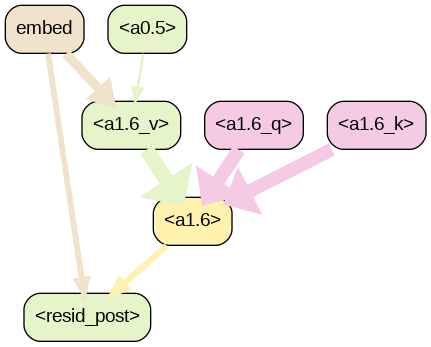

5 --------------------------------------------------
Edges remaining: 190
No edge 190
New metric: 3.7045090198516846

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.1.hook_k_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 0] is 7.403685092926025 (and current metric 3.7045090198516846)
Result is 3.699176073074341...so keeping connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 1]) (self.current_node=TLACDCInterpNode(blocks.1.hook_k_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 1] is 3.639735460281372 (and current metric 3.7045090198516846)
Result is -0.0647735595703125...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 2]) (self.current_node=TLACDCInterpNode(blocks.1.hook_k_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 2] is 

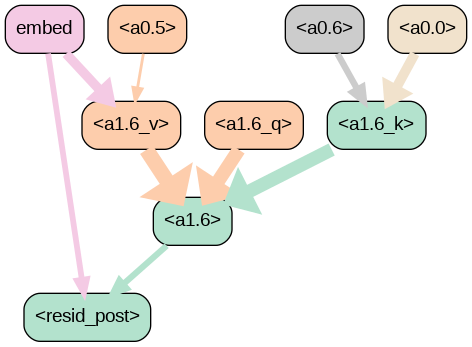

6 --------------------------------------------------
Edges remaining: 120
No edge 120
New metric: 3.6957809925079346

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.1.hook_q_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 0] is 3.791846752166748 (and current metric 3.6957809925079346)
Result is 0.09606575965881348...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 1]) (self.current_node=TLACDCInterpNode(blocks.1.hook_q_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 1] is 3.9670569896698 (and current metric 3.791846752166748)
Result is 0.17521023750305176...so removing connection

Node: cur_parent=TLACDCInterpNode(blocks.0.attn.hook_result, [:, :, 2]) (self.current_node=TLACDCInterpNode(blocks.1.hook_q_input, [:, :, 6]))

Metric after removing connection to blocks.0.attn.hook_result [:, :, 2] is 

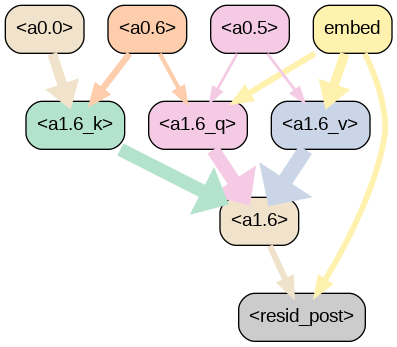

7 --------------------------------------------------
Edges remaining: 60
No edge 60
New metric: 5.2962727546691895
No edge 60
No edge 60
No edge 60
We moved to  blocks.0.attn.hook_result[:, :, 5]
No edge 60
No edge 60
8 --------------------------------------------------
Edges remaining: 60
No edge 60
New metric: 5.2962727546691895
No edge 60
No edge 60
No edge 60
We moved to  blocks.0.attn.hook_result[:, :, 4]
No edge 60
No edge 60
But it's bad
We moved to  blocks.0.attn.hook_result[:, :, 3]
No edge 60
No edge 60
But it's bad
We moved to  blocks.0.attn.hook_result[:, :, 2]
No edge 60
No edge 60
But it's bad
We moved to  blocks.0.attn.hook_result[:, :, 1]
No edge 60
No edge 60
But it's bad
We moved to  blocks.0.attn.hook_result[:, :, 0]
No edge 60
No edge 60
9 --------------------------------------------------
Edges remaining: 60
No edge 60
New metric: 5.2962727546691895
No edge 60
No edge 60
No edge 60
We moved to  blocks.0.attn.hook_v[:, :, 7]
No edge 60
No edge 59
But it's bad
We mov

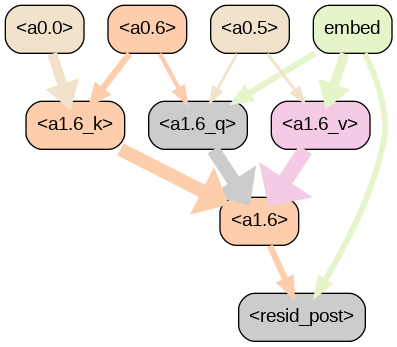

10 --------------------------------------------------
Edges remaining: 59
No edge 59
New metric: 5.2962727546691895

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_v, [:, :, 6]))

Metric after removing connection to blocks.0.hook_v_input [:, :, 6] is 6.59025239944458 (and current metric 5.2962727546691895)
Result is 1.2939796447753906...so keeping connection
No edge 59
We moved to  blocks.0.attn.hook_v[:, :, 5]
No edge 59
No edge 59
11 --------------------------------------------------
Edges remaining: 59
No edge 59
New metric: 5.2962727546691895

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_v, [:, :, 5]))

Metric after removing connection to blocks.0.hook_v_input [:, :, 5] is 6.634415149688721 (and current metric 5.2962727546691895)
Result is 1.3381423950195312...so keeping connection
No edge 59
We moved to  blocks.0.attn.hook_v[:, :

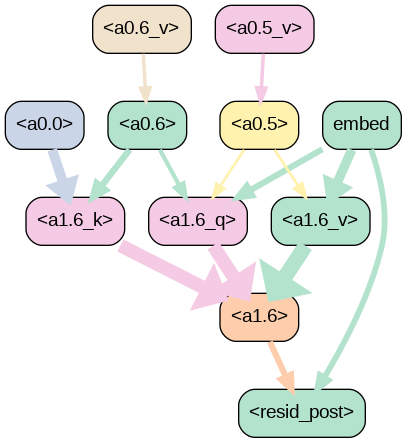

12 --------------------------------------------------
Edges remaining: 55
No edge 55
New metric: 5.2962727546691895

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_v, [:, :, 0]))

Metric after removing connection to blocks.0.hook_v_input [:, :, 0] is 7.616225719451904 (and current metric 5.2962727546691895)
Result is 2.319952964782715...so keeping connection
No edge 55
We moved to  blocks.0.attn.hook_k[:, :, 7]
No edge 55
No edge 54
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 6]
No edge 54
No edge 54
Edge removed! New set: 54


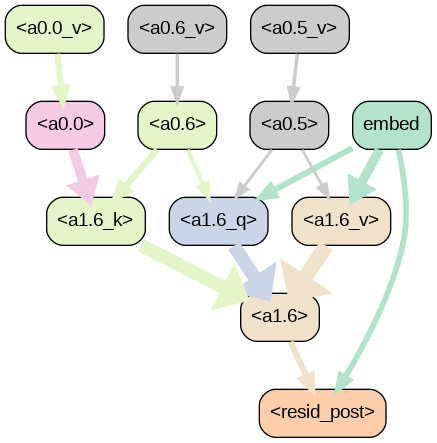

13 --------------------------------------------------
Edges remaining: 54
No edge 54
New metric: 5.2962727546691895

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_k_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_k, [:, :, 6]))

Metric after removing connection to blocks.0.hook_k_input [:, :, 6] is 5.746665000915527 (and current metric 5.2962727546691895)
Result is 0.4503922462463379...so removing connection
No edge 53
We moved to  blocks.0.attn.hook_k[:, :, 5]
No edge 53
No edge 53
Edge removed! New set: 53


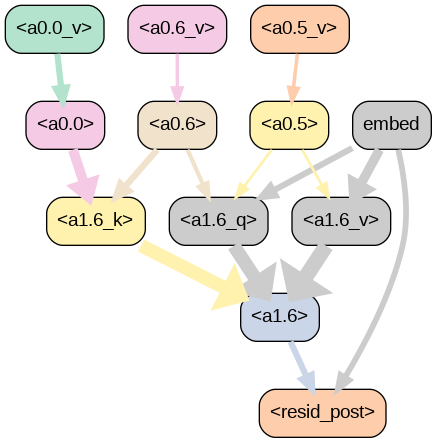

14 --------------------------------------------------
Edges remaining: 53
No edge 53
New metric: 5.746665000915527

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_k_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_k, [:, :, 5]))

Metric after removing connection to blocks.0.hook_k_input [:, :, 5] is 6.755908012390137 (and current metric 5.746665000915527)
Result is 1.0092430114746094...so keeping connection
No edge 53
We moved to  blocks.0.attn.hook_k[:, :, 4]
No edge 53
No edge 52
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 3]
No edge 52
No edge 51
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 2]
No edge 51
No edge 50
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 1]
No edge 50
No edge 49
But it's bad
We moved to  blocks.0.attn.hook_k[:, :, 0]
No edge 49
No edge 49
Edge removed! New set: 49


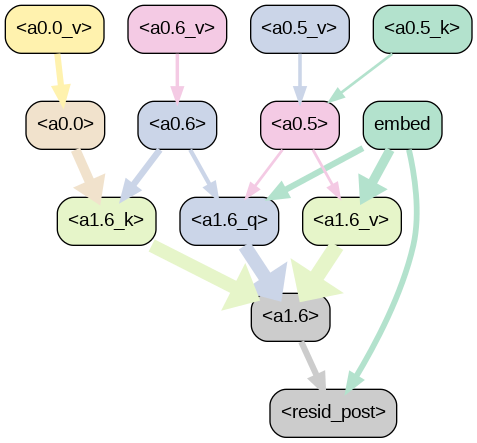

15 --------------------------------------------------
Edges remaining: 49
No edge 49
New metric: 5.746665000915527

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_k_input, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_k, [:, :, 0]))

Metric after removing connection to blocks.0.hook_k_input [:, :, 0] is 5.866591453552246 (and current metric 5.746665000915527)
Result is 0.11992645263671875...so removing connection
No edge 48
We moved to  blocks.0.attn.hook_q[:, :, 7]
No edge 48
No edge 47
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 6]
No edge 47
No edge 47
Edge removed! New set: 47


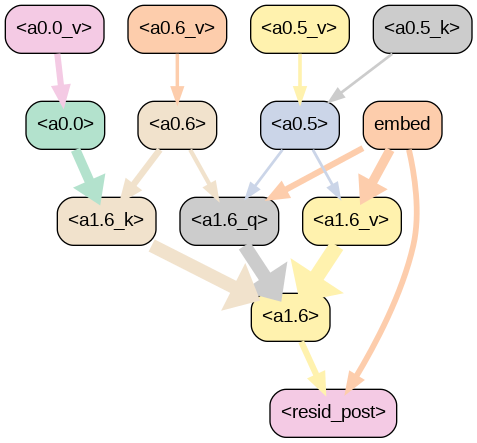

16 --------------------------------------------------
Edges remaining: 47
No edge 47
New metric: 5.866591453552246

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_q_input, [:, :, 6]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_q, [:, :, 6]))

Metric after removing connection to blocks.0.hook_q_input [:, :, 6] is 5.852916717529297 (and current metric 5.866591453552246)
Result is -0.013674736022949219...so removing connection
No edge 46
We moved to  blocks.0.attn.hook_q[:, :, 5]
No edge 46
No edge 46
Edge removed! New set: 46


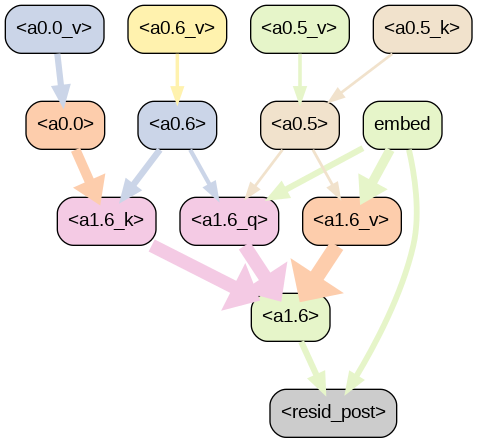

17 --------------------------------------------------
Edges remaining: 46
No edge 46
New metric: 5.852916717529297

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_q_input, [:, :, 5]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_q, [:, :, 5]))

Metric after removing connection to blocks.0.hook_q_input [:, :, 5] is 7.020090103149414 (and current metric 5.852916717529297)
Result is 1.1671733856201172...so keeping connection
No edge 46
We moved to  blocks.0.attn.hook_q[:, :, 4]
No edge 46
No edge 45
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 3]
No edge 45
No edge 44
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 2]
No edge 44
No edge 43
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 1]
No edge 43
No edge 42
But it's bad
We moved to  blocks.0.attn.hook_q[:, :, 0]
No edge 42
No edge 42
Edge removed! New set: 42


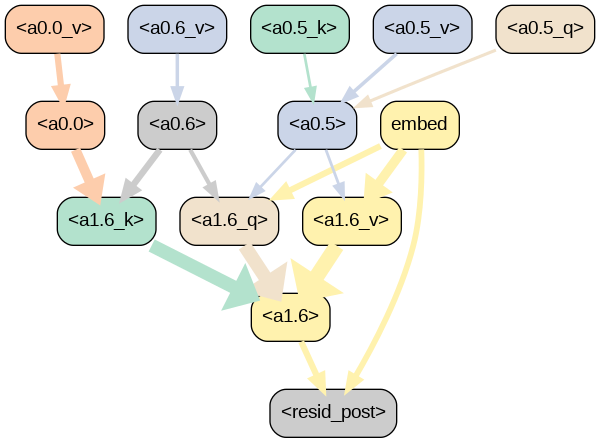

18 --------------------------------------------------
Edges remaining: 42
No edge 42
New metric: 5.852916717529297

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_q_input, [:, :, 0]) (self.current_node=TLACDCInterpNode(blocks.0.attn.hook_q, [:, :, 0]))

Metric after removing connection to blocks.0.hook_q_input [:, :, 0] is 6.008749008178711 (and current metric 5.852916717529297)
Result is 0.15583229064941406...so removing connection
No edge 41
We moved to  blocks.0.hook_v_input[:, :, 7]
No edge 41
No edge 40
But it's bad
We moved to  blocks.0.hook_v_input[:, :, 6]
No edge 40
No edge 40
Edge removed! New set: 40


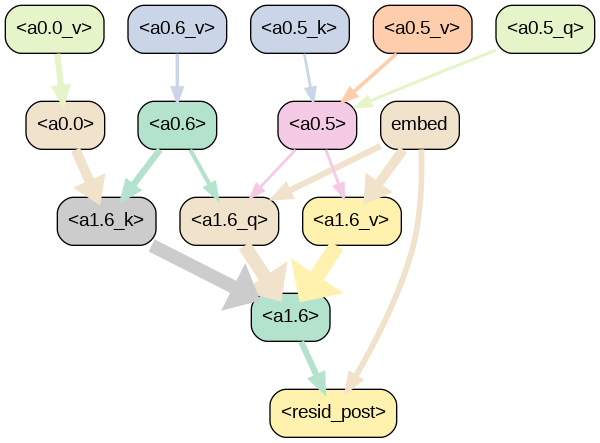

19 --------------------------------------------------
Edges remaining: 40
No edge 40
New metric: 6.008749008178711

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 6]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 6.790705680847168 (and current metric 6.008749008178711)
Result is 0.781956672668457...so removing connection
No edge 39
We moved to  blocks.0.hook_v_input[:, :, 5]
No edge 39
No edge 39
Edge removed! New set: 39


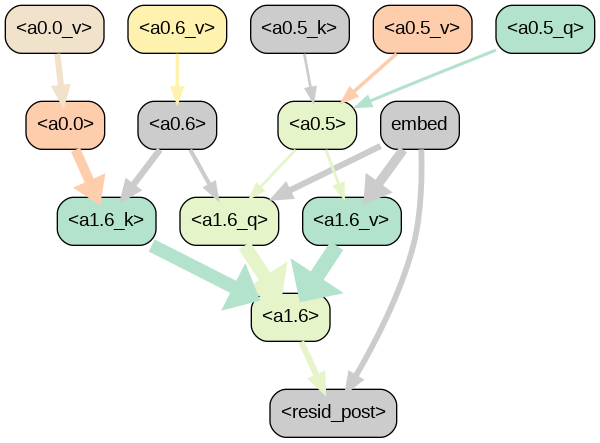

20 --------------------------------------------------
Edges remaining: 39
No edge 39
New metric: 6.790705680847168

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 5]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 7.452432632446289 (and current metric 6.790705680847168)
Result is 0.6617269515991211...so removing connection
No edge 38
We moved to  blocks.0.hook_v_input[:, :, 4]
No edge 38
No edge 37
But it's bad
We moved to  blocks.0.hook_v_input[:, :, 3]
No edge 37
No edge 36
But it's bad
We moved to  blocks.0.hook_v_input[:, :, 2]
No edge 36
No edge 35
But it's bad
We moved to  blocks.0.hook_v_input[:, :, 1]
No edge 35
No edge 34
But it's bad
We moved to  blocks.0.hook_v_input[:, :, 0]
No edge 34
No edge 34
Edge removed! New set: 34


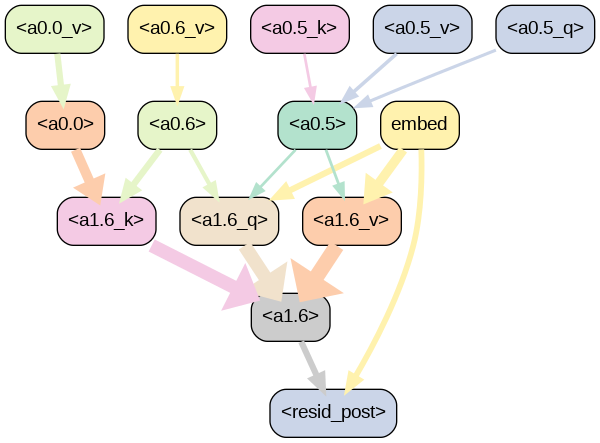

21 --------------------------------------------------
Edges remaining: 34
No edge 34
New metric: 7.452432632446289

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_v_input, [:, :, 0]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 7.809586048126221 (and current metric 7.452432632446289)
Result is 0.35715341567993164...so removing connection
No edge 33
We moved to  blocks.0.hook_k_input[:, :, 7]
No edge 33
No edge 32
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 6]
No edge 32
No edge 31
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 5]
No edge 31
No edge 31
Edge removed! New set: 31


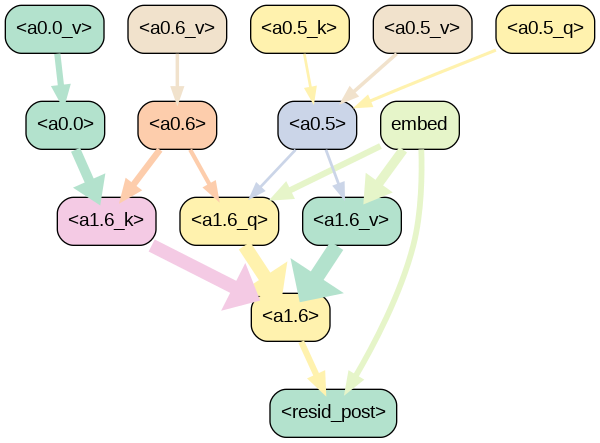

22 --------------------------------------------------
Edges remaining: 31
No edge 31
New metric: 7.809586048126221

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_k_input, [:, :, 5]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 7.791928291320801 (and current metric 7.809586048126221)
Result is -0.017657756805419922...so removing connection
No edge 30
We moved to  blocks.0.hook_k_input[:, :, 4]
No edge 30
No edge 29
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 3]
No edge 29
No edge 28
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 2]
No edge 28
No edge 27
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 1]
No edge 27
No edge 26
But it's bad
We moved to  blocks.0.hook_k_input[:, :, 0]
No edge 26
No edge 25
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 7]
No edge 25
No edge 24
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 6]
No edge 24
No edge 23
But it's bad
We 

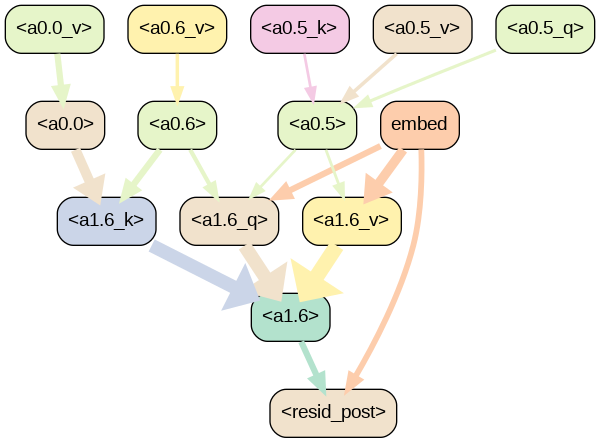

23 --------------------------------------------------
Edges remaining: 23
No edge 23
New metric: 7.791928291320801

Node: cur_parent=TLACDCInterpNode(blocks.0.hook_resid_pre, [:]) (self.current_node=TLACDCInterpNode(blocks.0.hook_q_input, [:, :, 5]))

Metric after removing connection to blocks.0.hook_resid_pre [:] is 7.805881500244141 (and current metric 7.791928291320801)
Result is 0.013953208923339844...so removing connection
No edge 22
We moved to  blocks.0.hook_q_input[:, :, 4]
No edge 22
No edge 21
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 3]
No edge 21
No edge 20
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 2]
No edge 20
No edge 19
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 1]
No edge 19
No edge 18
But it's bad
We moved to  blocks.0.hook_q_input[:, :, 0]
No edge 18
No edge 17
But it's bad
We moved to  blocks.0.hook_resid_pre[:]
No edge 17
No edge 17
Edge removed! New set: 17


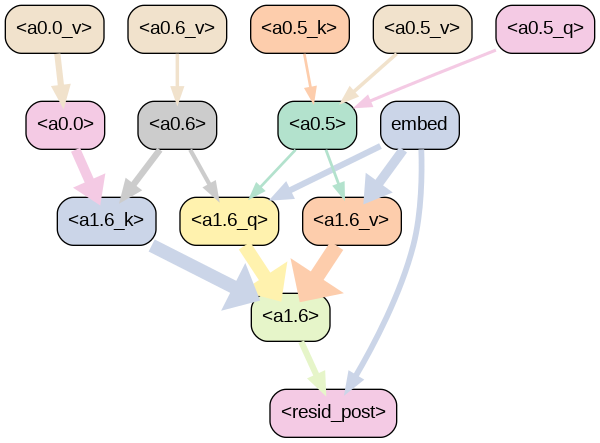

24 --------------------------------------------------
Edges remaining: 17
No edge 17
New metric: 7.805881500244141
We moved to  None
No edge 17
No edge 17
25 --------------------------------------------------
Edges remaining: 17


/content/Automatic-Circuit-Discovery/acdc/TLACDCExperiment.py:760: UserWarning: Finished iterating
  warnings.warn("Finished iterating")


In [32]:

import datetime
exp_time = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# for i in range(args.max_num_epochs):
#     exp.step(testing=False)

#     show(
#         exp.corr,
#         f"ims/img_new_{i+1}.png",
#         show_full_index=False,
#     )

#     if IN_COLAB or ipython is not None:
#         # so long as we're not running this as a script, show the image!
#         display(Image(f"ims/img_new_{i+1}.png"))

#     print(i, "-" * 50)
#     print(exp.count_no_edges())

#     if i == 0:
#         exp.save_edges("edges.pkl")

#     if exp.current_node is None or SINGLE_STEP:
#         show(
#             exp.corr,
#             f"ims/ACDC_img_{exp_time}.png",

#         )
#         break

# exp.save_edges("another_final_edges.pkl")

#DISPLAY GRAPH WHEN EDGE IS REMOVED
last_edge_count = exp.count_no_edges()

for i in range(args.max_num_epochs):
    exp.step(testing=False)

    current_edge_count = exp.count_no_edges()

    if current_edge_count < last_edge_count:
        print(f"Edge removed! New set: {current_edge_count}")

        fname = f"ims/img_pruned_{i+1}.png"
        show(exp.corr, fname=fname, show_full_index=False)

        if IN_COLAB or ipython is not None:
            display(Image(fname))

        last_edge_count = current_edge_count

    print(i, "-" * 50)
    print(f"Edges remaining: {current_edge_count}")

    if i == 0:
        exp.save_edges("edges.pkl")

    if exp.current_node is None or SINGLE_STEP:
        show(exp.corr, f"ims/ACDC_img_{exp_time}.png")
        break

if USING_WANDB:
    edges_fname = f"edges.pth"
    exp.save_edges(edges_fname)
    artifact = wandb.Artifact(edges_fname, type="dataset")
    artifact.add_file(edges_fname)
    wandb.log_artifact(artifact)
    os.remove(edges_fname)
    wandb.finish()


<h2>Save the final subgraph of the model</h2>
<p>There are more than `exp.count_no_edges()` here because we include some "placeholder" edges needed to make ACDC work that don't actually matter</p>
<p>Also note that the final image has more than 12 edges, because the edges from a0.0_q and a0.0_k are not connected to the input</p>
<p>We recover minimal induction machinery! `embed -> a0.0_v -> a1.6k`</p>

In [33]:
exp.save_subgraph(
    return_it=True,
)

OrderedDict([(('blocks.1.hook_resid_post',
               (None,),
               'blocks.1.attn.hook_result',
               (None, None, 6)),
              True),
             (('blocks.1.hook_resid_post',
               (None,),
               'blocks.0.hook_resid_pre',
               (None,)),
              True),
             (('blocks.1.attn.hook_result',
               (None, None, 6),
               'blocks.1.attn.hook_q',
               (None, None, 6)),
              True),
             (('blocks.1.attn.hook_result',
               (None, None, 6),
               'blocks.1.attn.hook_k',
               (None, None, 6)),
              True),
             (('blocks.1.attn.hook_result',
               (None, None, 6),
               'blocks.1.attn.hook_v',
               (None, None, 6)),
              True),
             (('blocks.1.attn.hook_q',
               (None, None, 6),
               'blocks.1.hook_q_input',
               (None, None, 6)),
              True),
        